# Working on Real Project with Python on 'COVID-19 Dataset'

# COVID-19 SMALL DATASET

We have taken a small dataset of Covid-19, just for your understaning purpose. You have to work on the original dataset which contains about 19000 rows.

The data used here is till 29-April-2020 and has records as on 29-April-2020.

This data is available as a CSV file, downloaded from Kaggle.

We will analyze this data using the Pandas DataFrame.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
csv=r"/content/Covid_19_data.csv"

In [3]:
df=pd.read_csv(csv)

In [4]:
df

,Date,State,Region,Confirmed,Deaths,Recovered
0,4/29/2020,NaN,Afghanistan,1939,60,252
1,4/29/2020,NaN,Albania,766,30,455
2,4/29/2020,NaN,Algeria,3848,444,1702
3,4/29/2020,NaN,Andorra,743,42,423
4,4/29/2020,NaN,Angola,27,2,7
...,...,...,...,...,...,...
316,4/29/2020,Wyoming,US,545,7,0
317,4/29/2020,Xinjiang,Mainland China,76,3,73
318,4/29/2020,Yukon,Canada,11,0,0
319,4/29/2020,Yunnan,Mainland China,185,2,181


# How to Analyze DataFrames ?

# .head()
It shows the first N rows in the data (by default, N=5).

In [34]:
df.head(5)

,Date,Region,Confirmed,Deaths,Recovered,year,month,day,Weekday
0,2020-04-29,Afghanistan,1939,60,252,2020,4,29,Wednesday
1,2020-04-29,Albania,766,30,455,2020,4,29,Wednesday
2,2020-04-29,Algeria,3848,444,1702,2020,4,29,Wednesday
3,2020-04-29,Andorra,743,42,423,2020,4,29,Wednesday
4,2020-04-29,Angola,27,2,7,2020,4,29,Wednesday


# .Shape
It shows the total no.of rows & columns.

In [6]:
df.shape

(321, 6)

# .info()
It provides basic information about dataframe.

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       321 non-null    datetime64[ns]
 1   Region     321 non-null    object        
 2   Confirmed  321 non-null    int64         
 3   Deaths     321 non-null    int64         
 4   Recovered  321 non-null    int64         
 5   year       321 non-null    int32         
 6   month      321 non-null    int32         
 7   day        321 non-null    int32         
 8   Weekday    321 non-null    object        
dtypes: datetime64[ns](1), int32(3), int64(3), object(2)
memory usage: 18.9+ KB


# .index
It provides the index of the dataframe.

In [10]:
df.index

RangeIndex(start=0, stop=321, step=1)

# .columns
It shows each column names.

In [9]:
df.columns

Index(['Date', 'State', 'Region', 'Confirmed', 'Deaths', 'Recovered'], dtype='object')

# .dtypes
It shows the datatypes of each column.

In [11]:
df.dtypes

,0
Date,object
State,object
Region,object
Confirmed,int64
Deaths,int64
Recovered,int64


# .describe
It breifly describes the data in statistics.

In [13]:
df.describe()

,Confirmed,Deaths,Recovered
count,321.000000,321.000000,321.000000
mean,9949.800623,709.152648,3030.277259
std,31923.853086,3236.162817,14364.870365
min,0.000000,0.000000,0.000000
25%,104.000000,2.000000,2.000000
50%,653.000000,12.000000,73.000000
75%,4655.000000,144.000000,587.000000
max,299691.000000,27682.000000,132929.000000


# .isnull().sum()
It shows the no. of null values of each column.

In [33]:
df.isnull().sum()

,0
Date,0
Region,0
Confirmed,0
Deaths,0
Recovered,0
year,0
month,0
day,0
Weekday,0


In [31]:
df[''],inplace=True)
df.head(10)

,Date,Region,Confirmed,Deaths,Recovered,year,month,day,Weekday
0,2020-04-29,Afghanistan,1939,60,252,2020,4,29,Wednesday
1,2020-04-29,Albania,766,30,455,2020,4,29,Wednesday
2,2020-04-29,Algeria,3848,444,1702,2020,4,29,Wednesday
3,2020-04-29,Andorra,743,42,423,2020,4,29,Wednesday
4,2020-04-29,Angola,27,2,7,2020,4,29,Wednesday
5,2020-04-29,Antigua and Barbuda,24,3,11,2020,4,29,Wednesday
6,2020-04-29,Argentina,4285,214,1192,2020,4,29,Wednesday
7,2020-04-29,Armenia,1932,30,900,2020,4,29,Wednesday
8,2020-04-29,Austria,15402,580,12779,2020,4,29,Wednesday
9,2020-04-29,Azerbaijan,1766,23,1267,2020,4,29,Wednesday


###Date formatting

In [32]:
df['Date']=pd.to_datetime(df['Date'])
df['year']=df['Date'].dt.year
df['month']=df['Date'].dt.month
df['day']=df['Date'].dt.day
df['Weekday']=df['Date'].dt.day_name()

df.head(2)

,Date,Region,Confirmed,Deaths,Recovered,year,month,day,Weekday
0,2020-04-29,Afghanistan,1939,60,252,2020,4,29,Wednesday
1,2020-04-29,Albania,766,30,455,2020,4,29,Wednesday


#Real World problems to solve

### Q.1 ) Show the number of Confirmed , Deaths and Recovered cases in each Region.

In [53]:
df.groupby('Region')[['Confirmed','Deaths','Recovered']].sum()

,Confirmed,Deaths,Recovered
Region,,,
Afghanistan,1939,60,252
Albania,766,30,455
Algeria,3848,444,1702
Andorra,743,42,423
Angola,27,2,7
...,...,...,...
West Bank and Gaza,344,2,71
Western Sahara,6,0,5
Yemen,6,0,1


### Q.2 ) Which are the top 10 most affected countries by: confirmed cases, deaths

In [85]:
df.groupby('Region')[['Confirmed','Deaths']].sum().sort_values(['Confirmed','Deaths'],ascending=False).head(10)

,Confirmed,Deaths
Region,,
US,1039909,60967
Spain,236899,24275
Italy,203591,27682
France,166536,24121
UK,166432,26165
Germany,161539,6467
Turkey,117589,3081
Russia,99399,972
Iran,93657,5957


### Q3) Remove all the records where Confirmed Cases is Less Than 10.

In [82]:
df=df[~(df.Confirmed < 10)]
df.head(50)

,Date,Region,Confirmed,Deaths,Recovered,year,month,day,Weekday
0,2020-04-29,Afghanistan,1939,60,252,2020,4,29,Wednesday
1,2020-04-29,Albania,766,30,455,2020,4,29,Wednesday
2,2020-04-29,Algeria,3848,444,1702,2020,4,29,Wednesday
3,2020-04-29,Andorra,743,42,423,2020,4,29,Wednesday
4,2020-04-29,Angola,27,2,7,2020,4,29,Wednesday
5,2020-04-29,Antigua and Barbuda,24,3,11,2020,4,29,Wednesday
6,2020-04-29,Argentina,4285,214,1192,2020,4,29,Wednesday
7,2020-04-29,Armenia,1932,30,900,2020,4,29,Wednesday
8,2020-04-29,Austria,15402,580,12779,2020,4,29,Wednesday
9,2020-04-29,Azerbaijan,1766,23,1267,2020,4,29,Wednesday


### Q.4) In which Region, maximum number of Confirmed cases were recorded ?

In [84]:
df.groupby('Region')['Confirmed'].sum().sort_values(ascending=False).head(20)

,Confirmed
Region,
US,1039909
Spain,236899
Italy,203591
France,166536
UK,166432
Germany,161539
Turkey,117589
Russia,99399
Iran,93657


### Q.5) In which Region, minimum number of Deaths cases were recorded ?

In [86]:
df.groupby('Region')['Deaths'].sum().sort_values(ascending=True).head(20)

,Deaths
Region,
Cambodia,0
Fiji,0
Dominica,0
Central African Republic,0
Eritrea,0
Laos,0
Holy See,0
Nepal,0
Madagascar,0


### Q.6) How many Confirmed , Deaths & Recovered cases were reported from India till 29 April 2020 ?**bold text**

In [90]:
df[df.Region=='India']

,Date,Region,Confirmed,Deaths,Recovered,year,month,day,Weekday
74,2020-04-29,India,33062,1079,8437,2020,4,29,Wednesday


### Q.7) Find recovery rate per country. Compare high recovery vs low recovery regions.

In [91]:
df.groupby('Region')['Recovered'].sum().sort_values(ascending=False)

,Recovered
Region,
Spain,132929
Germany,120400
Mainland China,77609
Iran,73791
Italy,71252
...,...
Cabo Verde,2
Holy See,2
Canada,0


### Q.8) Find the date with highest spike in cases globally.

In [97]:
daily_cases = df.groupby('Date')['Confirmed'].sum()

spike_date = daily_cases.idxmax()
spike_value = daily_cases.max()

print("Highest Spike Date:", spike_date)
print("Cases on that day:", spike_value)

Highest Spike Date: 2020-04-29 00:00:00
Cases on that day: 3193807


### Q.9) Compare 5 countries:
India,
USA,
Brazil,
Russia,
UK.

Plot trend lines in one graph.

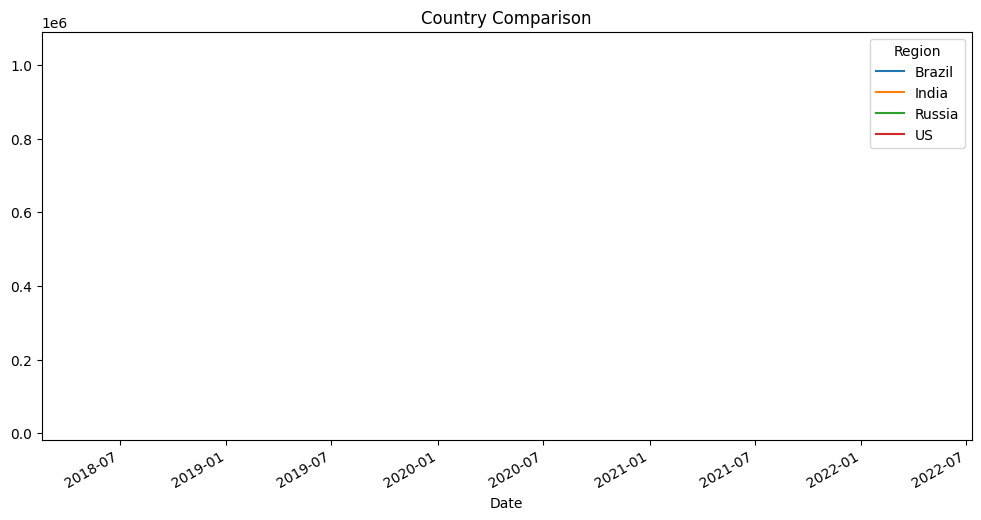

In [103]:
countries = ['India', 'US', 'Brazil', 'Russia', 'United Kingdom']

filtered = df[df['Region'].isin(countries)]

country_trend = filtered.groupby(['Date', 'Region'])['Confirmed'].sum().unstack()

country_trend.plot(figsize=(12,6))
plt.title("Country Comparison")
plt.show()

### Q.10) Which country controlled the spread fastest?
Define metric:

time to flatten curve
drop in daily cases

In [101]:
# Daily growth
df_sorted = df.sort_values(['Region', 'Date'])

df_sorted['Daily Change'] = df_sorted.groupby('Region')['Confirmed'].diff()

# Average growth per country
growth = df_sorted.groupby('Region')['Daily Change'].mean().sort_values()

growth.head(10)  # lower = better control

,Daily Change
Region,
UK,-20651.125000
France,-20631.875000
Netherlands,-12909.000000
Denmark,-4498.500000
Canada,-468.545455
US,-113.696429
Mainland China,9.551724
Australia,63.571429
Afghanistan,NaN


### Q.11) Find correlation between:

confirmed cases, deaths, recoveries.

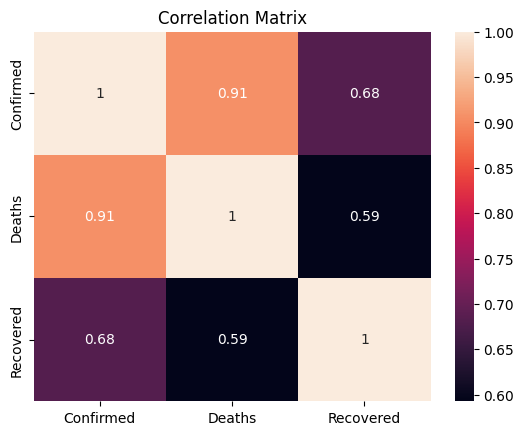

In [104]:
corr = df[['Confirmed', 'Deaths', 'Recovered']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

#Feature Engineering

Create new columns:

* Active cases = Confirmed - Deaths - Recovered


* Mortality rate


* Recovery ratio

In [107]:
df['Active Cases'] = df['Confirmed'] - df['Deaths'] - df['Recovered']

df['Mortality Rate'] = (df['Deaths'] / df['Confirmed']) * 100

df['Recovery Ratio'] = (df['Recovered'] / df['Confirmed']) * 100

df.head()

,Date,Region,Confirmed,Deaths,Recovered,year,month,day,Weekday,Active Cases,Mortality Rate,Recovery Ratio
0,2020-04-29,Afghanistan,1939,60,252,2020,4,29,Wednesday,1627,3.094379,12.996390
1,2020-04-29,Albania,766,30,455,2020,4,29,Wednesday,281,3.916449,59.399478
2,2020-04-29,Algeria,3848,444,1702,2020,4,29,Wednesday,1702,11.538462,44.230769
3,2020-04-29,Andorra,743,42,423,2020,4,29,Wednesday,278,5.652759,56.931359
4,2020-04-29,Angola,27,2,7,2020,4,29,Wednesday,18,7.407407,25.925926


In [111]:
df['Mortality Rate'] = np.where(df['Confirmed'] > 0,
                               (df['Deaths'] / df['Confirmed']) * 100,
                               0)
df.head()

,Date,Region,Confirmed,Deaths,Recovered,year,month,day,Weekday,Active Cases,Mortality Rate,Recovery Ratio
0,2020-04-29,Afghanistan,1939,60,252,2020,4,29,Wednesday,1627,3.094379,12.996390
1,2020-04-29,Albania,766,30,455,2020,4,29,Wednesday,281,3.916449,59.399478
2,2020-04-29,Algeria,3848,444,1702,2020,4,29,Wednesday,1702,11.538462,44.230769
3,2020-04-29,Andorra,743,42,423,2020,4,29,Wednesday,278,5.652759,56.931359
4,2020-04-29,Angola,27,2,7,2020,4,29,Wednesday,18,7.407407,25.925926


# Visualization (Python – Clean & Interpretable)

##Top 10 Countries (Bar Chart)

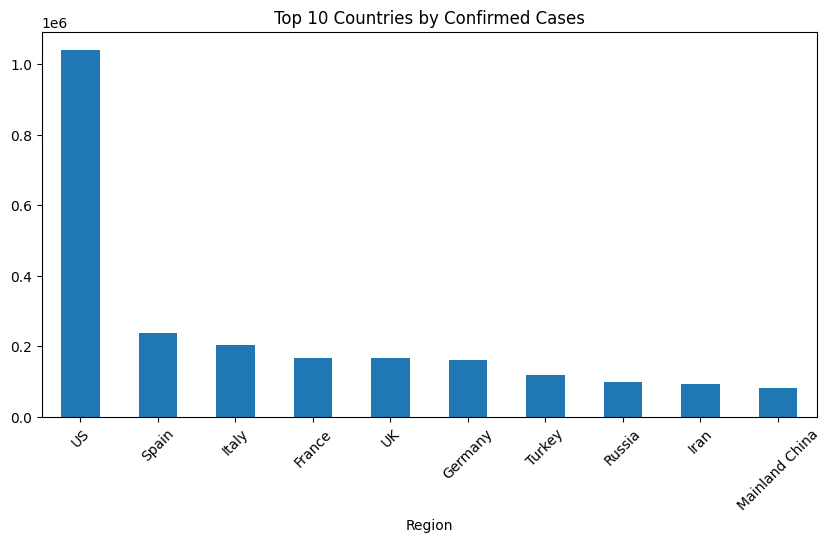

In [112]:
top10 = df.groupby('Region')['Confirmed'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title("Top 10 Countries by Confirmed Cases")
plt.xticks(rotation=45)
plt.show()

##Global Trend (Line Chart)

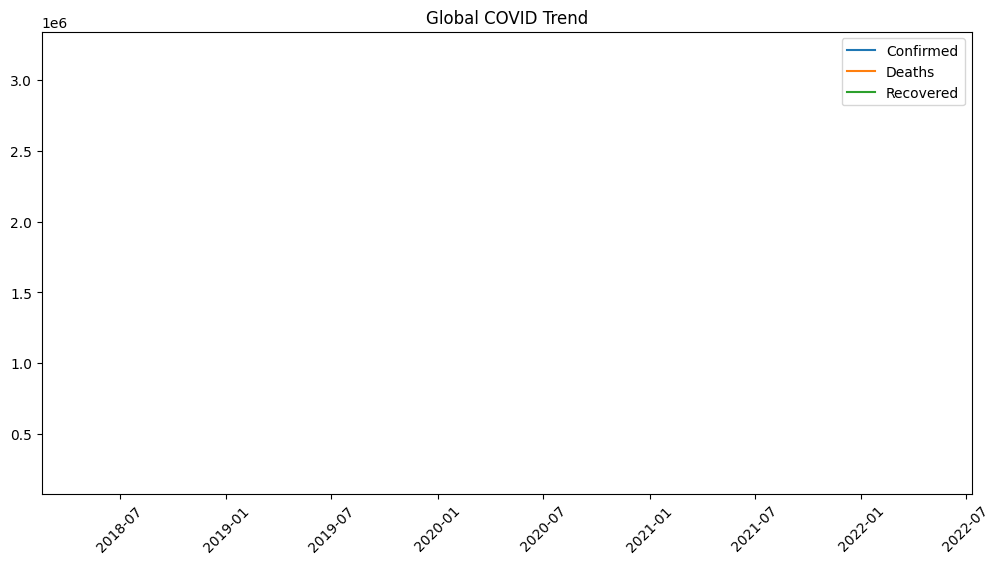

In [113]:
global_trend = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum()

plt.figure(figsize=(12,6))
plt.plot(global_trend.index, global_trend['Confirmed'], label='Confirmed')
plt.plot(global_trend.index, global_trend['Deaths'], label='Deaths')
plt.plot(global_trend.index, global_trend['Recovered'], label='Recovered')

plt.legend()
plt.title("Global COVID Trend")
plt.xticks(rotation=45)
plt.show()

##Distribution (Pie Chart)

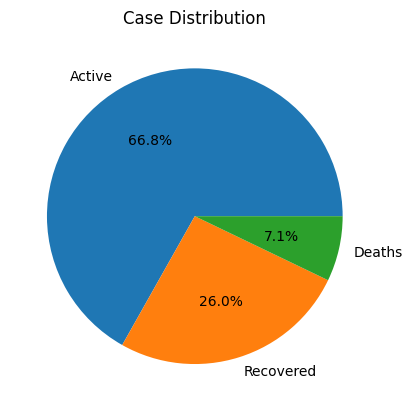

In [114]:
latest = df.groupby('Date')[['Confirmed','Deaths','Recovered']].sum().iloc[-1]

active = latest['Confirmed'] - latest['Deaths'] - latest['Recovered']

labels = ['Active', 'Recovered', 'Deaths']
values = [active, latest['Recovered'], latest['Deaths']]

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Case Distribution")
plt.show()

##Correlation Heatmap

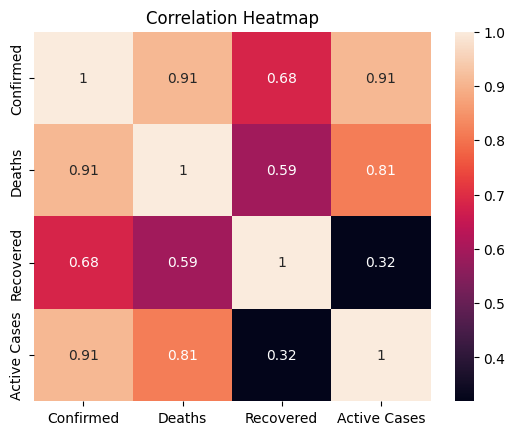

In [115]:
corr = df[['Confirmed', 'Deaths', 'Recovered', 'Active Cases']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [118]:
# Select relevant columns
powerbi_df = df[['Date', 'Region', 'Confirmed', 'Deaths', 'Recovered',
                 'Active Cases', 'Mortality Rate', 'Recovery Ratio']]

# Remove duplicates
powerbi_df = powerbi_df.drop_duplicates()

# Save
powerbi_df.to_csv('/content/covid_powerbi.csv', index=False)